In [42]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from mnist_classifier import MnistClassifier
from data import load_data
import numpy as np

In [25]:
import warnings
warnings.filterwarnings('ignore')

#### Load the MNIST dataset

In [26]:
X_train, y_train, X_test, y_test = load_data()

In [27]:
print(f"X_train.shape: {X_train.shape}, \ny_train.shape: {y_train.shape}, \nX_test.shape: {X_test.shape}, \ny_test.shape: {y_test.shape}")

X_train.shape: (60000, 784), 
y_train.shape: (60000,), 
X_test.shape: (10000, 784), 
y_test.shape: (10000,)


####  Common function to evaluate a model

In [28]:
def evaluate_model(clf_type, X_train, y_train, X_test, y_test, model_name):
    clf = MnistClassifier(clf_type)
    clf.train(X_train, y_train)
    predictions = clf.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    return predictions

#### Train all classifiers

In [29]:
# Random Forest
rf_predictions = evaluate_model("rf", X_train, y_train, X_test, y_test, "Random Forest")

Random Forest Accuracy: 0.9709


In [30]:
# Neural Network
nn_predictions = evaluate_model("nn", X_train, y_train, X_test, y_test, "Neural Network")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 721us/step - accuracy: 0.9284 - loss: 0.2433
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.9679 - loss: 0.1036
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 797us/step - accuracy: 0.9771 - loss: 0.0727
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.9823 - loss: 0.0549
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.9854 - loss: 0.0443
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step
Neural Network Accuracy: 0.9728


In [31]:
# CNN
cnn_predictions = evaluate_model("cnn", X_train, y_train, X_test, y_test, "CNN")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9602 - loss: 0.1293
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9866 - loss: 0.0428
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9906 - loss: 0.0288
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9934 - loss: 0.0207
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9950 - loss: 0.0157
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Accuracy: 0.9912


#### Visualization of predictions

In [32]:
def show_predictions(X_test, y_test, predictions, model_name, n=10):
    plt.figure(figsize=(15, 3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        plt.title(f"P:{predictions[i]}\nT:{y_test[i]}")
        plt.axis('off')
    plt.suptitle(model_name)
    plt.show()

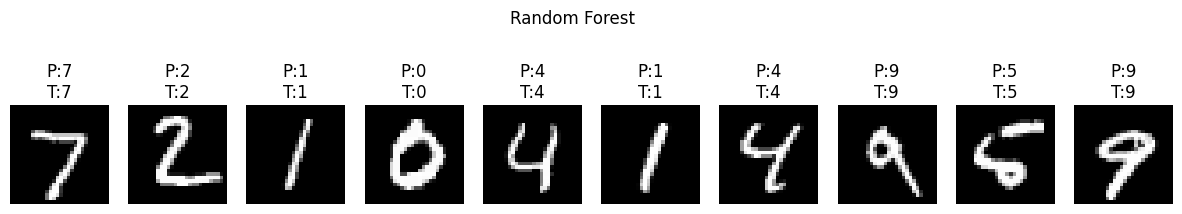

In [33]:
show_predictions(X_test, y_test, rf_predictions, "Random Forest")

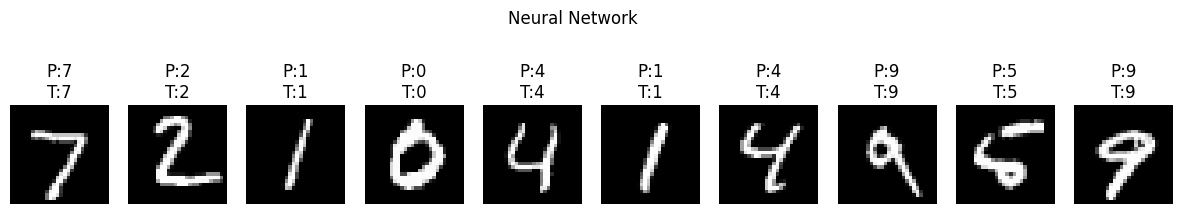

In [34]:
show_predictions(X_test, y_test, nn_predictions, "Neural Network")

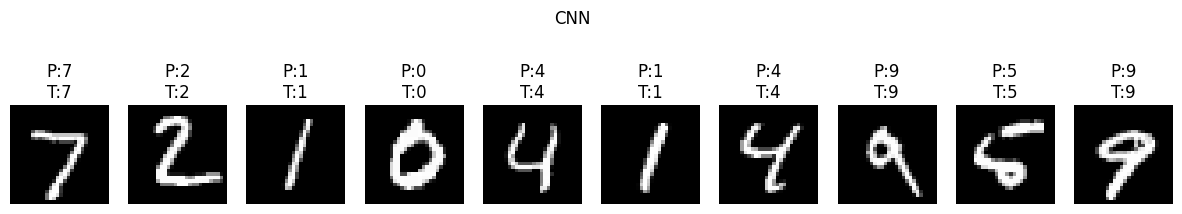

In [35]:
show_predictions(X_test, y_test, cnn_predictions, "CNN")

In [ ]:
def show_errors(X_test, y_test, predictions, model_name, n=10):
    # Find indices of misclassified samples
    errors = np.where(predictions != y_test)[0]
    
    plt.figure(figsize=(15, 3))
    for i in range(n):
        idx = errors[i]
        plt.subplot(1, n, i+1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"P:{predictions[idx]}\nT:{y_test[idx]}")
        plt.axis('off')

    plt.suptitle(f"{model_name} Errors")
    plt.show()

#### Display examples of errors

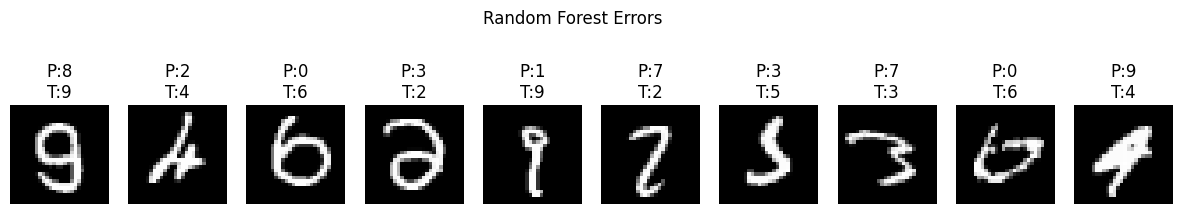

In [51]:
show_errors(X_test, y_test, rf_predictions, "Random Forest")

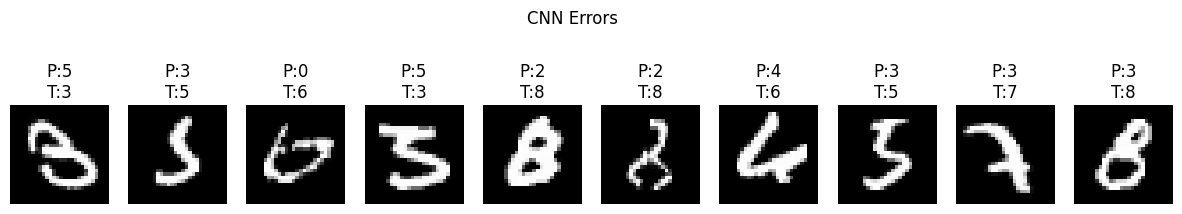

In [52]:
show_errors(X_test, y_test, cnn_predictions, "CNN")

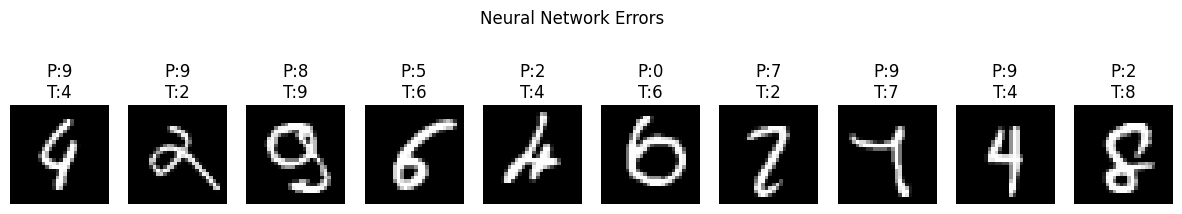

In [53]:
show_errors(X_test, y_test, nn_predictions, "Neural Network")

#### Edge Cases

1. Invalid algorithm

In [60]:
try:
    clf = MnistClassifier("xyz")
except ValueError as e:
    print(f"Error: {e}")

Error: Unsupported algorithm. Choose from 'rf', 'nn', or 'cnn'.


2. Empty dataset

In [62]:
try:
    X_empty = np.array([]).reshape(0, 784)
    clf = MnistClassifier("rf")
    clf.train(X_empty, np.array([]))
except Exception as e:
    print(f"Error: {e}")

Error: Found array with 0 sample(s) (shape=(0, 784)) while a minimum of 1 is required by RandomForestClassifier.


3. Mismatched input shapes

In [63]:
try:
    X_wrong = np.random.rand(10, 100)
    clf = MnistClassifier("rf")
    clf.train(X_train, y_train)
    clf.predict(X_wrong)
except Exception as e:
    print(f"Error: {e}")

Error: X has 100 features, but RandomForestClassifier is expecting 784 features as input.


4. Non-numeric data

In [64]:
try:
    X_strings = np.array([["a"] * 784])
    clf = MnistClassifier("rf")
    clf.train(X_strings, np.array([1]))
except Exception as e:
    print(f"Error: {e}")

Error: could not convert string to float: np.str_('a')


5. Single class in training data

In [65]:
try:
    X_single = X_train[y_train == 0]
    y_single = y_train[y_train == 0]
    clf = MnistClassifier("rf")
    clf.train(X_single, y_single)
    predictions = clf.predict(X_test)
    print(f"Accuracy with single class: {accuracy_score(y_test, predictions):.4f}")
except Exception as e:
    print(f"Error: {e}")

Accuracy with single class: 0.0980


The model was trained on only one number, so it predicts it for all
In the test dataset, it occurs in 9.8%